[✓] Save directory ready: RetinaViT_AD_Results/
[INFO] Loading ODIR-5K dataset …
[INFO] Rows      : 5000
[INFO] Loaded    : 7117 images  (skipped 0 unlabeled rows)
[INFO] Per-class : [1389  735  368  326  293  247  231  528]

[INFO] Split  |  Train: 3992  Val: 498  Test: 1621
[INFO] Building model …

Model: "RetinaViT_AD"
  input (InputLayer)                     (None,224,224,3)   0
  efficientnetb3 (Functional)            (None,7,7,1536)    10,783,535
  gam (GlobalAttentionModule)            (None,7,7,1536)    4,723,009
  to_tokens (Reshape)                    (None,49,1536)     0
  transformer (TransformerBlock)         (None,49,1536)     18,921,472
  gam_flat (Reshape)                     (None,49,1536)     0
  concat (Concatenate)                   (None,49,3072)     0
  fusion_1 (MultiHeadFusion)             (None,49,3072)     28,320,768
  fusion_2 (MultiHeadFusion)             (None,49,3072)     28,320,768
  gap (GlobalAvgPool1D)                  (None,3072)        0
  bn_head (B

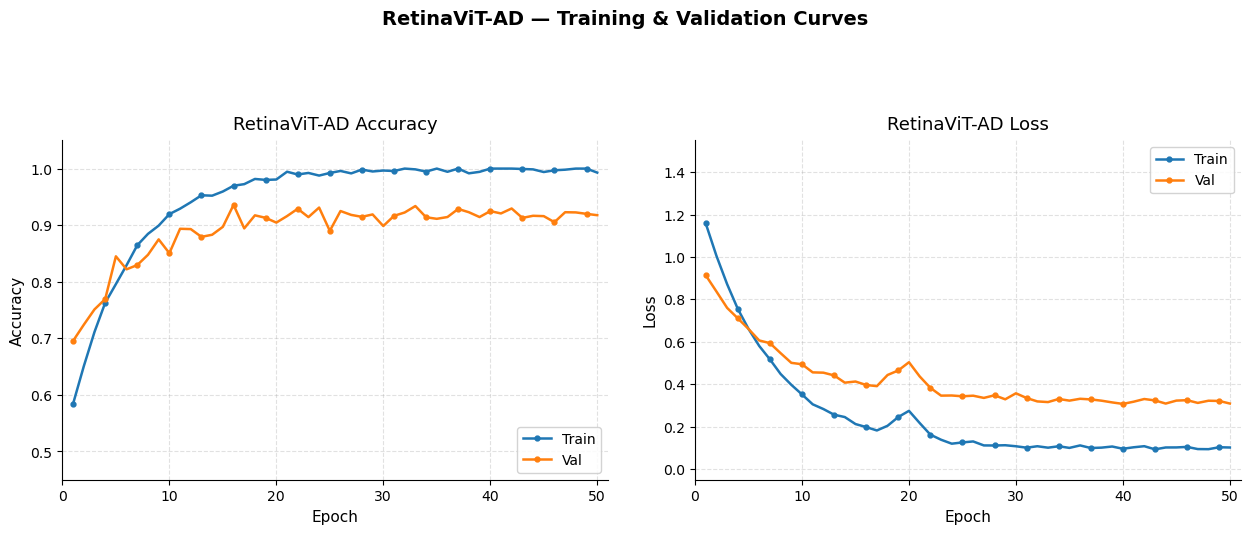

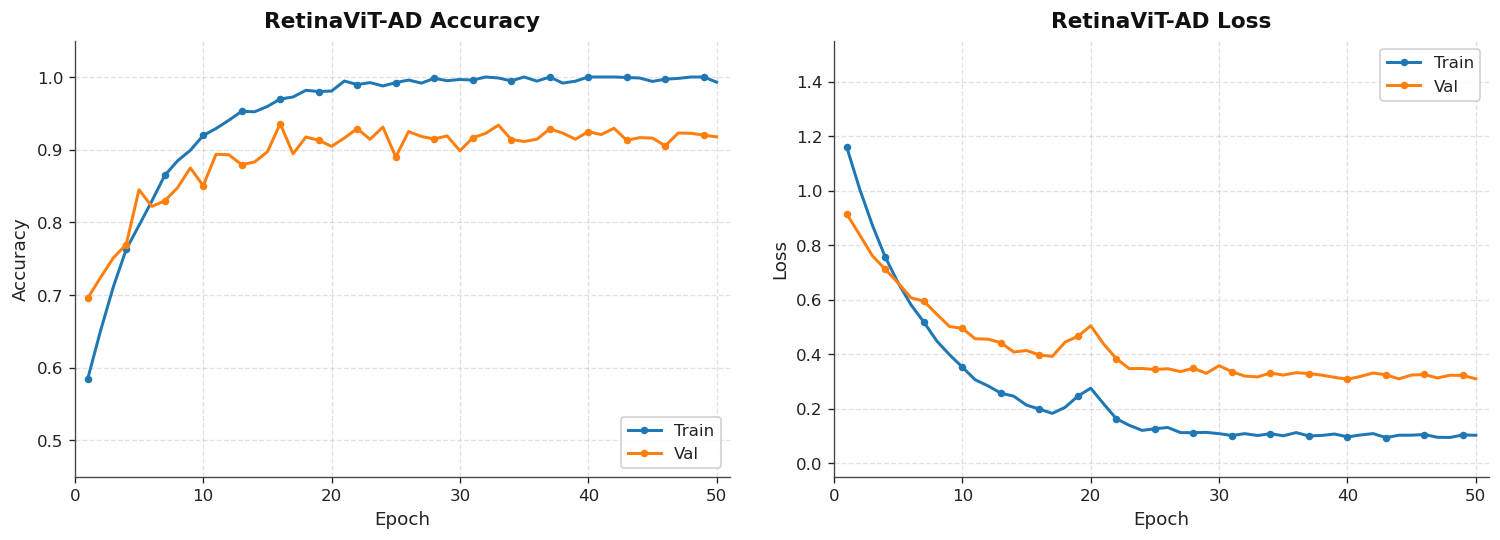

[✓] Saved: RetinaViT_AD_Results\confusion_matrix.png


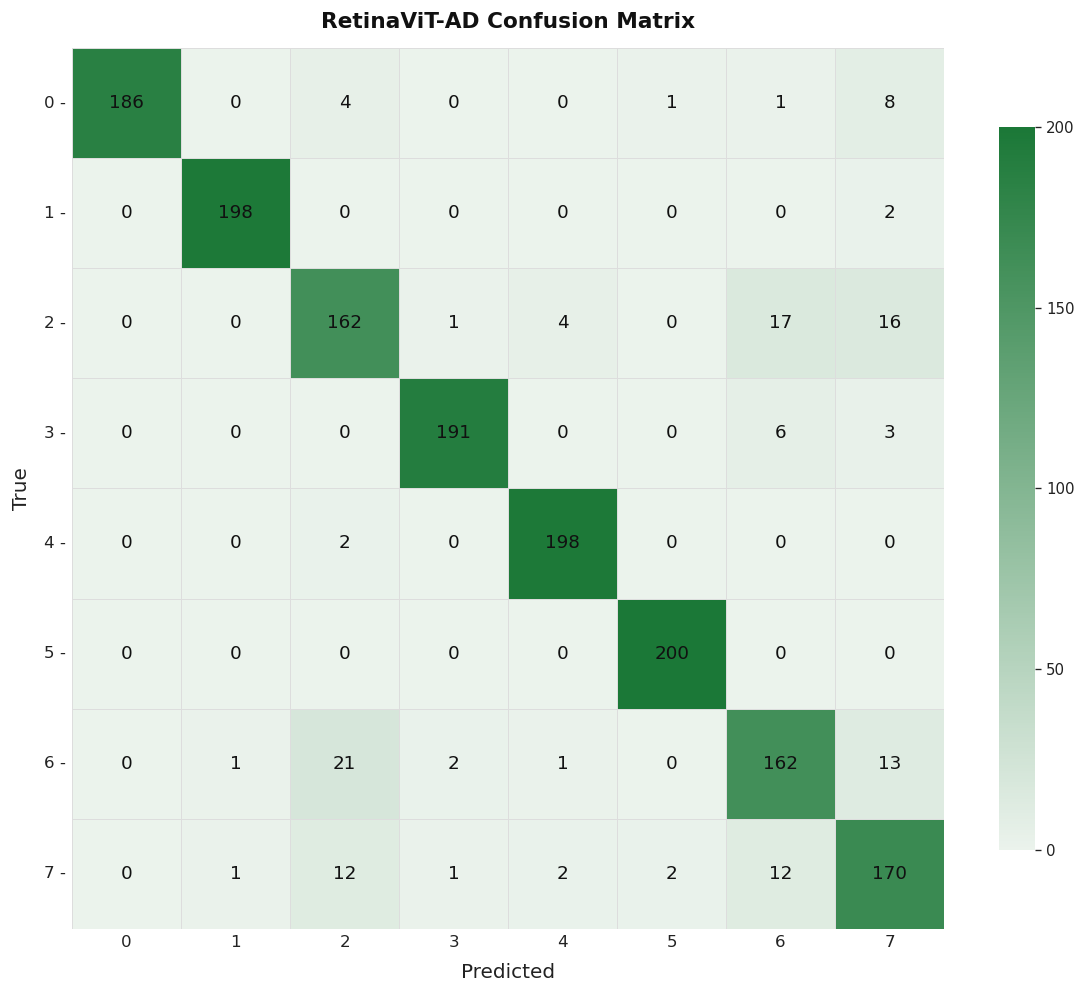

[✓] Saved: RetinaViT_AD_Results\roc_curves.png


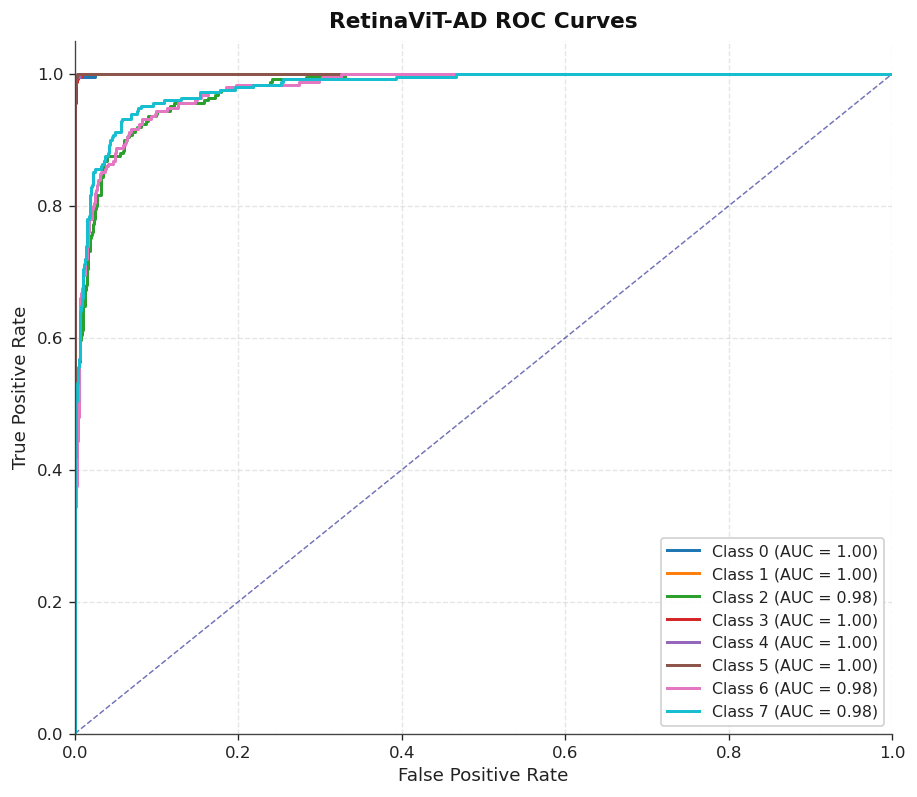


[✓] All results saved to: RetinaViT_AD_Results/


In [ ]:
"""
RetinaViT-AD: A Lightweight Hybrid CNN-Transformer Framework for
Explainable Multi-Class Retinal Disease Classification

Dataset  : ODIR-5K  →  D:\Dataset\Ocular Disease Recognition\ODIR-5K
Split    : 70% Train | 10% Val | 20% Test
Output   : trained model + train/val curves + confusion matrix + ROC curves
"""

# =============================================================================
# 1. IMPORTS
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc,
                             confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from scipy.special import ndtri

import cv2

np.random.seed(42)
tf.random.set_seed(42)

# ── IMPORTANT for Jupyter inline display ─────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    "figure.dpi"       : 120,
    "savefig.dpi"      : 180,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "#444444",
    "axes.labelcolor"  : "#222222",
    "xtick.color"      : "#222222",
    "ytick.color"      : "#222222",
    "text.color"       : "#222222",
    "grid.color"       : "#aaaaaa",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.35,
    "font.family"      : "DejaVu Sans",
})


# =============================================================================
# 2. CONFIGURATION
# =============================================================================
DATASET_ROOT = r"D:\Dataset\Ocular Disease Recognition\ODIR-5K"

# ODIR-5K standard folder structure
TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "ODIR-5K_Training_Images")
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, "ODIR-5K_Testing_Images")
TRAIN_CSV     = os.path.join(DATASET_ROOT,
                              "ODIR-5K_Training_Annotations(Updated)_V2.xlsx")

SAVE_DIR   = os.path.join(DATASET_ROOT, "RetinaViT_AD_Results")
MODEL_PATH = os.path.join(SAVE_DIR, "RetinaViT_AD_best.keras")

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-4
NUM_CLASSES = 8

CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract",
               "AMD", "Hypertension", "Myopia", "Other"]


os.makedirs(SAVE_DIR, exist_ok=True)
print(f"[INFO] Results will be saved to: {SAVE_DIR}")


# =============================================================================
# 3. DATA LOADING & PREPROCESSING
# =============================================================================

def load_odir_dataset(csv_path: str, img_dir: str):
    """
    Load ODIR-5K from annotation Excel/CSV.

    Expected columns:
        ID | Left-Fundus | Right-Fundus | N | D | G | C | A | H | M | O

    Returns
    -------
    images : np.ndarray  shape (N, 224, 224, 3)  float32 [0,1]
    labels : np.ndarray  shape (N,)              int32
    """
    print(f"\n[INFO] Reading annotations: {csv_path}")
    df = pd.read_excel(csv_path) if csv_path.endswith(".xlsx") \
         else pd.read_csv(csv_path)

    print(f"[INFO] Rows      : {len(df)}")
    print(f"[INFO] Columns   : {list(df.columns)}")

    label_cols = ["N", "D", "G", "C", "A", "H", "M", "O"]
    eye_cols   = ["Left-Fundus", "Right-Fundus"]

    for col in label_cols + eye_cols:
        if col not in df.columns:
            raise ValueError(
                f"Column '{col}' not found.\n"
                f"Available columns: {list(df.columns)}")

    images, labels = [], []
    skipped = 0

    for _, row in df.iterrows():
        # Primary label = index of the first column that equals 1
        label_idx = None
        for i, col in enumerate(label_cols):
            if row[col] == 1:
                label_idx = i
                break
        if label_idx is None:
            skipped += 1
            continue

        for col in eye_cols:
            fname = row[col]
            if pd.isna(fname):
                continue
            fpath = os.path.join(img_dir, str(fname))
            if not os.path.exists(fpath):
                continue

            img = cv2.imread(fpath)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(label_idx)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    print(f"[INFO] Loaded    : {len(images)} images  "
          f"(skipped {skipped} unlabeled rows)")
    print(f"[INFO] Per-class : {np.bincount(labels)}")
    return images, labels


def balance_dataset(X: np.ndarray, y: np.ndarray):
    """Oversample minority classes to max class count (Section 3.2.4)."""
    max_count = int(np.bincount(y).max())
    X_bal, y_bal = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        if len(idx) < max_count:
            idx = resample(idx, replace=True,
                           n_samples=max_count, random_state=42)
        X_bal.append(X[idx])
        y_bal.append(y[idx])
    X_bal = np.concatenate(X_bal)
    y_bal = np.concatenate(y_bal)
    perm  = np.random.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]


def make_dataset(X: np.ndarray, y: np.ndarray, augment: bool = False):
    """Build a tf.data pipeline (Section 3.2.5)."""
    y_oh = to_categorical(y, NUM_CLASSES).astype(np.float32)
    ds   = tf.data.Dataset.from_tensor_slices((X, y_oh))
    if augment:
        ds = ds.map(
            lambda img, lbl: (tf.image.random_flip_left_right(img), lbl),
            num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(
            lambda img, lbl: (tf.image.random_brightness(img, 0.10), lbl),
            num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(
            lambda img, lbl: (tf.image.random_contrast(img, 0.90, 1.10), lbl),
            num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


# =============================================================================
# 4. MODEL ARCHITECTURE — RetinaViT-AD
# =============================================================================

# ── 4.1 Channel Attention ────────────────────────────────────────────────────
class ChannelAttention(layers.Layer):
    """CA(F) = σ( W2 · ReLU( W1 · GAP(F) ) )  [Eq. 10]"""
    def __init__(self, channels, reduction=16, **kw):
        super().__init__(**kw)
        self.gap     = layers.GlobalAveragePooling2D()
        self.fc1     = layers.Dense(max(channels // reduction, 8),
                                    activation="relu")
        self.fc2     = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))

    def call(self, x):
        att = self.reshape(self.fc2(self.fc1(self.gap(x))))
        return x * att


# ── 4.2 Spatial Attention ────────────────────────────────────────────────────
class SpatialAttention(layers.Layer):
    """7×7 conv on avg+max pooled maps  [Eq. 9]"""
    def __init__(self, **kw):
        super().__init__(**kw)
        self.conv = layers.Conv2D(1, kernel_size=7, padding="same",
                                  activation="sigmoid")

    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)
        return x * self.conv(tf.concat([avg, mx], axis=-1))


# ── 4.3 Global Attention Module (GAM) ───────────────────────────────────────
class GlobalAttentionModule(layers.Layer):
    """F_GAM = F_CNN ⊙ CA(F_CNN) ⊙ SA(F_CNN)  [Eq. 9]"""
    def __init__(self, channels, **kw):
        super().__init__(**kw)
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def call(self, x):
        return self.sa(self.ca(x))


# ── 4.4 Transformer Block (Pre-LN) ──────────────────────────────────────────
class TransformerBlock(layers.Layer):
    """
    Pre-LN Transformer [Eq. 12-13]:
        8 heads | D=1536 | d_k=192/head | FFN_dim=2048 | Swish | dropout[0.1,0.4]
    """
    def __init__(self, embed_dim, num_heads, ff_dim,
                 dropout_rate=0.1, **kw):
        super().__init__(**kw)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout_rate)
        self.ffn   = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="swish"),
            layers.Dropout(dropout_rate),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout_rate)
        self.drop2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        n1 = self.norm1(x)
        x  = x + self.drop1(self.attn(n1, n1, training=training),
                             training=training)
        n2 = self.norm2(x)
        x  = x + self.drop2(self.ffn(n2, training=training),
                             training=training)
        return x


# ── 4.5 Multi-Head Fusion Block ──────────────────────────────────────────────
class MultiHeadFusionBlock(layers.Layer):
    """Two Dense layers to model cross-subspace interactions  [Eq. 15]"""
    def __init__(self, embed_dim, dropout_rate=0.3, **kw):
        super().__init__(**kw)
        self.d1 = layers.Dense(embed_dim, activation="swish")
        self.b1 = layers.BatchNormalization()
        self.p1 = layers.Dropout(dropout_rate)
        self.d2 = layers.Dense(embed_dim, activation="swish")
        self.b2 = layers.BatchNormalization()
        self.p2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        x = self.p1(self.b1(self.d1(x), training=training), training=training)
        x = self.p2(self.b2(self.d2(x), training=training), training=training)
        return x


# ── 4.6 Full RetinaViT-AD ────────────────────────────────────────────────────
def build_retinavit_ad() -> Model:
    """
    Pipeline (Figure 2):
      I → EfficientNetB3 → F_CNN ∈ R^{h×w×1536}
        → GAM            → F_GAM
        → Reshape        → X    ∈ R^{N×1536}
        → TransformerBlock → X_trans
        → Concat(F_GAM_flat, X_trans) → F_cat ∈ R^{N×3072}
        → MultiHeadFusion × 2         → F_fusion
        → GAP → BN → Dropout(0.4)    → Dense(8) → Softmax
    """
    EMBED_DIM = 1536   # EfficientNetB3 output channels
    NUM_HEADS = 8
    FF_DIM    = 2048
    DROPOUT   = 0.2

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input")

    # Stage 1: EfficientNetB3 (block6, block7, top fine-tuned)
    backbone = EfficientNetB3(include_top=False,
                              weights="imagenet",
                              input_tensor=inputs)
    for layer in backbone.layers:
        layer.trainable = False
    for layer in backbone.layers:
        if any(b in layer.name for b in ["block6", "block7", "top"]):
            layer.trainable = True

    F_cnn = backbone.output                                     # (B, h, w, 1536)

    # Stage 2: GAM
    F_gam = GlobalAttentionModule(EMBED_DIM, name="gam")(F_cnn) # (B, h, w, 1536)

    # Stage 3: Transformer
    X_tok   = layers.Reshape((-1, EMBED_DIM), name="to_tokens")(F_gam)
    X_trans = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM,
                                dropout_rate=DROPOUT,
                                name="transformer")(X_tok)       # (B, N, 1536)

    # Stage 4: Multi-Head Fusion
    F_flat = layers.Reshape((-1, EMBED_DIM), name="gam_flat")(F_gam)
    F_cat  = layers.Concatenate(axis=-1, name="concat")([F_flat, X_trans])
    F_fus  = MultiHeadFusionBlock(EMBED_DIM * 2, 0.3, name="fusion_1")(F_cat)
    F_fus  = MultiHeadFusionBlock(EMBED_DIM * 2, 0.3, name="fusion_2")(F_fus)

    # Stage 5: Classification head
    x   = layers.GlobalAveragePooling1D(name="gap")(F_fus)
    x   = layers.BatchNormalization(name="bn_head")(x)
    x   = layers.Dropout(0.4, name="dropout_head")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       name="predictions")(x)

    return Model(inputs, out, name="RetinaViT_AD")


# =============================================================================
# 5. TRAINING
# =============================================================================

def train_model(X_train, y_train, X_val, y_val):
    """Build, compile, and train the model. Returns (model, history)."""
    print("\n[INFO] Building model …")
    model = build_retinavit_ad()
    model.compile(
        optimizer=Adam(LR),
        loss=CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"])
    model.summary()

    # Balance + pipelines
    X_tr_b, y_tr_b = balance_dataset(X_train, y_train)
    ds_train = make_dataset(X_tr_b, y_tr_b, augment=True)
    ds_val   = make_dataset(X_val,  y_val,  augment=False)

    callbacks = [
        ModelCheckpoint(MODEL_PATH, monitor="val_accuracy",
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, verbose=1),
    ]

    print(f"\n[INFO] Training for up to {EPOCHS} epochs …")
    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1)

    print(f"\n[✓] Best model saved → {MODEL_PATH}")
    return model, history


# =============================================================================
# 6. PLOTS & RESULTS
# =============================================================================

def plot_train_val_curves(history):
    """Training & Validation Accuracy + Loss (Figure 6 in paper)."""
    ep  = np.arange(1, len(history.history["accuracy"]) + 1)
    kw  = dict(linewidth=1.8, marker="o", markersize=3.5, markevery=3)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                              facecolor="white")

    # ── Accuracy ────────────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor("white")
    ax.plot(ep, history.history["accuracy"],
            label="Train", color="#1f77b4", **kw)
    ax.plot(ep, history.history["val_accuracy"],
            label="Val",   color="#ff7f0e", **kw)
    ax.set_title("RetinaViT-AD Accuracy",
                 fontsize=13, fontweight="bold", color="#111111", pad=8)
    ax.set_xlabel("Epoch",    fontsize=11, color="#222222")
    ax.set_ylabel("Accuracy", fontsize=11, color="#222222")
    ax.set_xlim([0, len(ep) + 1])
    ax.set_ylim([0.45, 1.05])
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.legend(fontsize=10, loc="lower right",
              framealpha=0.9, edgecolor="#cccccc",
              facecolor="white", labelcolor="#222222")
    ax.grid(True, linestyle="--", alpha=0.35, color="#aaaaaa")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors="#222222")

    # ── Loss ─────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.set_facecolor("white")
    ax.plot(ep, history.history["loss"],
            label="Train", color="#1f77b4", **kw)
    ax.plot(ep, history.history["val_loss"],
            label="Val",   color="#ff7f0e", **kw)
    ax.set_title("RetinaViT-AD Loss",
                 fontsize=13, fontweight="bold", color="#111111", pad=8)
    ax.set_xlabel("Epoch", fontsize=11, color="#222222")
    ax.set_ylabel("Loss",  fontsize=11, color="#222222")
    ax.set_xlim([0, len(ep) + 1])
    ax.set_ylim([-0.05, 1.55])
    ax.legend(fontsize=10, loc="upper right",
              framealpha=0.9, edgecolor="#cccccc",
              facecolor="white", labelcolor="#222222")
    ax.grid(True, linestyle="--", alpha=0.35, color="#aaaaaa")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors="#222222")

    plt.tight_layout(pad=2.5)

    path = os.path.join(SAVE_DIR, "train_val_curves.png")
    plt.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    print(f"[✓] Saved: {path}")
    plt.show()          # ← inline display in Jupyter / VS Code notebook


def plot_confusion_matrix(y_true, y_pred):
    """Confusion matrix (Figure 7 in paper)."""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8.5), facecolor="white")
    ax.set_facecolor("white")

    cmap = sns.light_palette("#1b7837", as_cmap=True)
    sns.heatmap(
        cm,
        annot=True, fmt="d",
        cmap=cmap,
        xticklabels=range(NUM_CLASSES),
        yticklabels=[f"{i} -" for i in range(NUM_CLASSES)],
        linewidths=0.4, linecolor="#dddddd",
        annot_kws={"size": 11, "color": "#111111"},
        cbar_kws={"shrink": 0.82},
        ax=ax)

    cbar = ax.collections[0].colorbar
    cbar.set_ticks([0, 50, 100, 150, 200])
    cbar.ax.tick_params(labelsize=9, colors="#222222")
    cbar.outline.set_edgecolor("#cccccc")

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10,
                        color="#222222", rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10,
                        color="#222222", rotation=0)
    ax.set_xlabel("Predicted", fontsize=12, color="#222222", labelpad=8)
    ax.set_ylabel("True",      fontsize=12, color="#222222", labelpad=8)
    ax.set_title("RetinaViT-AD Confusion Matrix",
                 fontsize=13, fontweight="bold", color="#111111", pad=12)
    ax.tick_params(colors="#222222", length=0)

    plt.tight_layout(pad=1.5)

    path = os.path.join(SAVE_DIR, "confusion_matrix.png")
    plt.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    print(f"[✓] Saved: {path}")
    plt.show()          # ← inline display in Jupyter / VS Code notebook


def plot_roc_curves(y_true, y_scores):
    """ROC Curves for all classes (Figure 8 in paper)."""
    y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

    COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
              "#9467bd", "#8c564b", "#e377c2", "#17becf"]

    fig, ax = plt.subplots(figsize=(8, 7), facecolor="white")
    ax.set_facecolor("white")
    ax.plot([0, 1], [0, 1], "--", color="navy", lw=0.9, alpha=0.55)

    for c in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_scores[:, c])
        ra = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8, color=COLORS[c],
                label=f"Class {c} (AUC = {ra:.2f})")

    ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11, color="#222222")
    ax.set_ylabel("True Positive Rate",  fontsize=11, color="#222222")
    ax.set_title("RetinaViT-AD ROC Curves",
                 fontsize=13, fontweight="bold", color="#111111", pad=8)
    ax.legend(loc="lower right", fontsize=9.5,
              framealpha=0.9, edgecolor="#cccccc",
              facecolor="white", labelcolor="#222222",
              handlelength=2.0)
    ax.grid(True, linestyle="--", alpha=0.30, color="#aaaaaa")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors="#222222")

    plt.tight_layout(pad=2.0)

    path = os.path.join(SAVE_DIR, "roc_curves.png")
    plt.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    print(f"[✓] Saved: {path}")
    plt.show()          # ← inline display in Jupyter / VS Code notebook


def print_and_save_results(y_true, y_pred):
    """Print classification report and overall metrics; save to .txt."""
    report = classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES, digits=4)
    acc  = accuracy_score (y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec  = recall_score   (y_true, y_pred, average="weighted")
    f1   = f1_score       (y_true, y_pred, average="weighted")

    print("\n" + "="*65)
    print("  RetinaViT-AD — Test Set Results")
    print("="*65)
    print(report)
    print(f"  Overall Accuracy  : {acc :.4f}  ({acc *100:.2f}%)")
    print(f"  Overall Precision : {prec:.4f}  ({prec*100:.2f}%)")
    print(f"  Overall Recall    : {rec :.4f}  ({rec *100:.2f}%)")
    print(f"  Overall F1-Score  : {f1  :.4f}  ({f1  *100:.2f}%)")
    print("="*65 + "\n")

    path = os.path.join(SAVE_DIR, "classification_report.txt")
    with open(path, "w") as fh:
        fh.write("RetinaViT-AD — Test Set Results\n" + "="*65 + "\n")
        fh.write(report)
        fh.write(f"\nAccuracy  : {acc:.4f}\nPrecision : {prec:.4f}\n"
                 f"Recall    : {rec:.4f}\nF1-Score  : {f1:.4f}\n")
    print(f"[✓] Saved: {path}")


# =============================================================================
# 7. MAIN
# =============================================================================

def main():
    # ── 1. Load ODIR-5K ──────────────────────────────────────────────────
    X, y = load_odir_dataset(TRAIN_CSV, TRAIN_IMG_DIR)

    # ── 2. Stratified 70 / 10 / 20 split ────────────────────────────────
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42)

    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.111,        # 0.111 × 0.80 ≈ 10% of total
        stratify=y_trainval,
        random_state=42)

    print(f"\n[INFO] Split  |  Train: {len(X_train)}  "
          f"Val: {len(X_val)}  Test: {len(X_test)}")

    # ── 3. Train ─────────────────────────────────────────────────────────
    model, history = train_model(X_train, y_train, X_val, y_val)

    # ── 4. Training curves ────────────────────────────────────────────────
    print("\n[INFO] Generating figures …\n")
    plot_train_val_curves(history)

    # ── 5. Test evaluation ────────────────────────────────────────────────
    print("\n[INFO] Evaluating on held-out test set …")
    ds_test   = make_dataset(X_test, y_test, augment=False)
    y_scores  = model.predict(ds_test, verbose=1)
    y_pred    = np.argmax(y_scores, axis=1)

    print_and_save_results(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)
    plot_roc_curves(y_test, y_scores)

    print(f"\n[✓] All results saved to: {SAVE_DIR}")


if __name__ == "__main__":
    main()